# Example 03_long_episode_applicability

Real data (paper Appendix F, Table F2). Baseline feasibility (Eq. 9) and common-transition feasibility (Eq. 26) are different conditions; the admitted subset uses its own D_A and mean delay in Eq. (27). The output is the admitted-subset speed-only emissions.

This notebook runs `run.py` in this folder and shows its outputs. Inputs are in `config.json`; expected values are in `expected/results.json`.

In [1]:
import json, runpy, sys
from pathlib import Path
from IPython.display import Image, display
HERE = Path.cwd()
try:
    runpy.run_path(str(HERE / 'run.py'), run_name='__main__')
except SystemExit as e:
    print('exit status', e.code)

LONG EPISODE (Appendix F, Table F2): state_transition__AZ_I10_W::78__2016-04-01__027
  D = 4689 veh/lane, P_hat = 4.37 h, v_q = 13.48 mph, peak delay 3.34 min, mean delay 1.45 min
1. baseline (Eq. 9): allowance 3.66 min -> peak-delay vehicle fits
2. transitions (Eq. 26, a = 1.5/1.0 m/s^2): T_down 22.7 s, T_up 34.0 s, band 0.37-1.88 min
   cohort inside 29.5%, below 31.0% (near onset and clearance), above 39.4% (near the peak)
   admitted subset: D_A = 1385 veh/lane, own mean delay wbar_A = 1.060 min (episode mean 1.453 min)
3. admitted-subset speed-only emissions, Eq. (27), per lane (not the full-episode total; no operating-mode term):
   CO2  de_tr = -20.72 g/veh;  E_A = 4.68e+05 g;  using the episode mean delay instead: 5.009e+05 g (+7.05%)
   NOx  de_tr = -0.03961 g/veh;  E_A = 464.9 g;  using the episode mean delay instead: 445.2 g (-4.24%)
   CO   de_tr = -0.04772 g/veh;  E_A = 3789 g;  using the episode mean delay instead: 4216 g (+11.28%)
   HC   de_tr = -0.002607 g/veh;  E_A = 

compared 47 values with expected/results.json: 47 agree
exit status 0


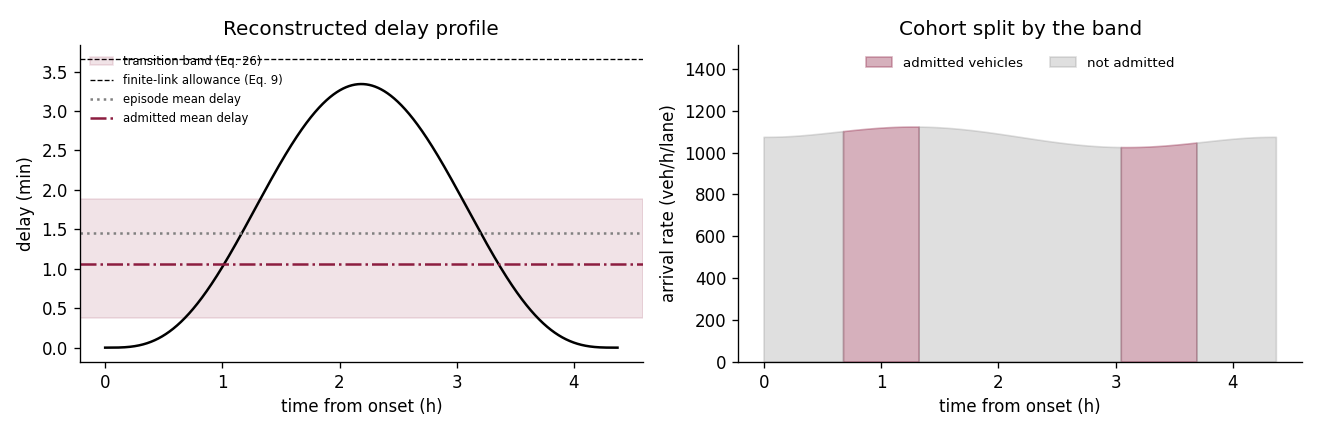

In [2]:
display(Image(filename=str(HERE / 'figure.png')))

In [3]:
res = json.loads((HERE / 'results.json').read_text())
print(json.dumps({k: v for k, v in res.items() if k != 'provenance'}, indent=1)[:3000])
print('provenance:', res['provenance'])

{
 "episode": {
  "id": "state_transition__AZ_I10_W::78__2016-04-01__027",
  "D_veh_lane": 4688.7444444444445,
  "P_hat_h": 4.371538409470127,
  "x_h": 3.1224662366062472,
  "vf_mph": 64.16137486955441,
  "vq_hat_mph": 13.478312831438965,
  "L_mi": 1.0400000000000205,
  "peak_delay_min": 3.342419279844996,
  "mean_delay_min": 1.453382063558382,
  "reconstructed_D_veh_lane": 4688.744444444445,
  "lambda_min_vphpl": 1023.5713952137253
 },
 "baseline_Eq9": {
  "allowance_min": 3.6571118328688113,
  "peak_vehicle_ok": true
 },
 "transition_Eq26": {
  "T_down_s": 22.657356053519127,
  "T_up_s": 33.98603408027869,
  "w_lo_min": 0.3728697706937075,
  "w_hi_min": 1.8821243077833278,
  "share_inside_pct": 29.530000000000005,
  "share_below_pct": 31.025,
  "share_above_pct": 39.445,
  "D_A_veh_lane": 1384.586234444445,
  "wbar_A_min": 1.0598938129906974
 },
 "admitted_subset_speed_only_emissions": {
  "CO2": {
   "de_tr_g_per_veh": -20.716453834020598,
   "E_A_g_lane": 467973.3364926938,
   "dir